# 05 — Unsupervised Learning

No labels here — the model only sees `X` and has to find structure on its
own: groups of similar points (clustering), a lower-dimensional view of the
data (dimensionality reduction), or points that don't fit the pattern
(anomaly detection).

**Covered:**
1. K-Means Clustering
2. Hierarchical Clustering
3. DBSCAN
4. PCA (dimensionality reduction)
5. t-SNE (visualization)
6. Anomaly Detection (Isolation Forest, One-Class SVM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, load_wine, load_digits

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(4)

## 1. K-Means Clustering

**Theory.** Pick `k` cluster centers ("centroids"), then iterate: (1) assign
each point to its nearest centroid, (2) move each centroid to the mean of
its assigned points. Repeats until convergence. Minimizes within-cluster
variance (inertia). Assumes roughly spherical, similarly-sized clusters, and
`k` must be chosen in advance.

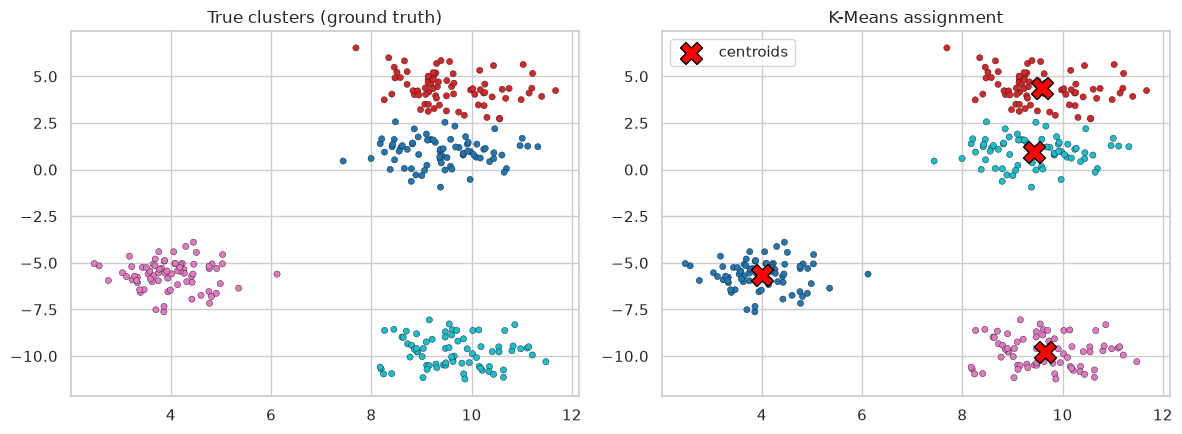

In [2]:
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=4)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, n_init=10, random_state=4)
kmeans_labels = kmeans.fit_predict(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs_true, cmap="tab10", s=20, edgecolor="k", linewidth=0.3)
axes[0].set_title("True clusters (ground truth)")

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=kmeans_labels, cmap="tab10", s=20, edgecolor="k", linewidth=0.3)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker="X", s=250, color="red", edgecolor="black", label="centroids")
axes[1].set_title("K-Means assignment")
axes[1].legend()
plt.tight_layout()
plt.show()

**Choosing k.** Since K-Means needs `k` up front, two common tools help pick it:
- **Elbow method** — plot inertia (within-cluster sum of squares) vs. `k`; look for where the drop-off flattens.
- **Silhouette score** — measures how well-separated clusters are (range -1 to 1, higher is better); doesn't require ground truth labels.

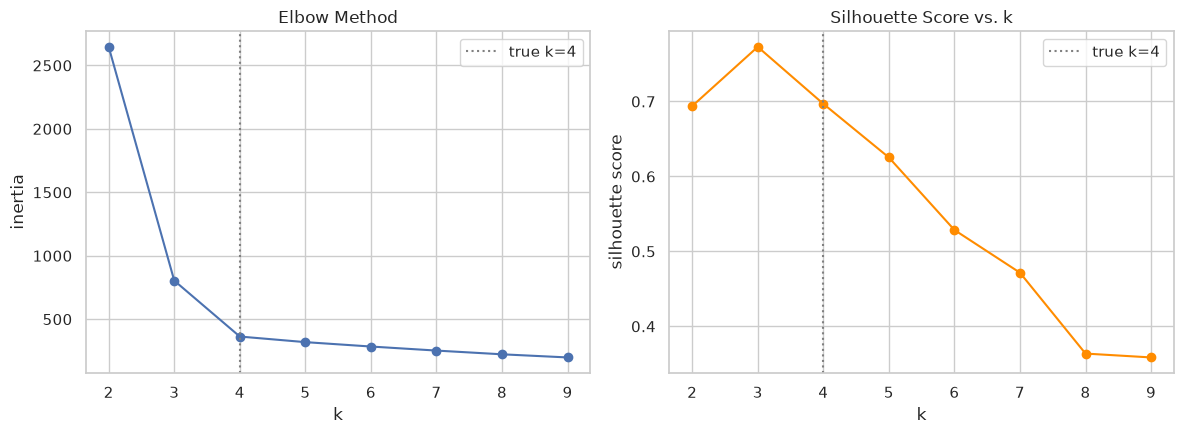

In [3]:
from sklearn.metrics import silhouette_score

k_range = range(2, 10)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=4).fit(X_blobs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blobs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_range, inertias, marker="o")
axes[0].axvline(4, color="gray", linestyle=":", label="true k=4")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow Method")
axes[0].legend()

axes[1].plot(k_range, silhouettes, marker="o", color="darkorange")
axes[1].axvline(4, color="gray", linestyle=":", label="true k=4")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette Score vs. k")
axes[1].legend()
plt.tight_layout()
plt.show()

Both plots point to `k=4` — the elbow's bend and the silhouette score's peak
line up with the true number of clusters we generated.

## 2. Hierarchical Clustering

**Theory.** Builds a tree of clusters bottom-up (agglomerative): start with
every point as its own cluster, then repeatedly merge the two closest
clusters (by some **linkage** rule — e.g., `ward` minimizes the increase in
within-cluster variance) until one cluster remains. The merge order is drawn
as a **dendrogram**, and cutting it at a chosen height gives any number of
clusters after the fact — unlike K-Means, you don't have to commit to `k`
before fitting.

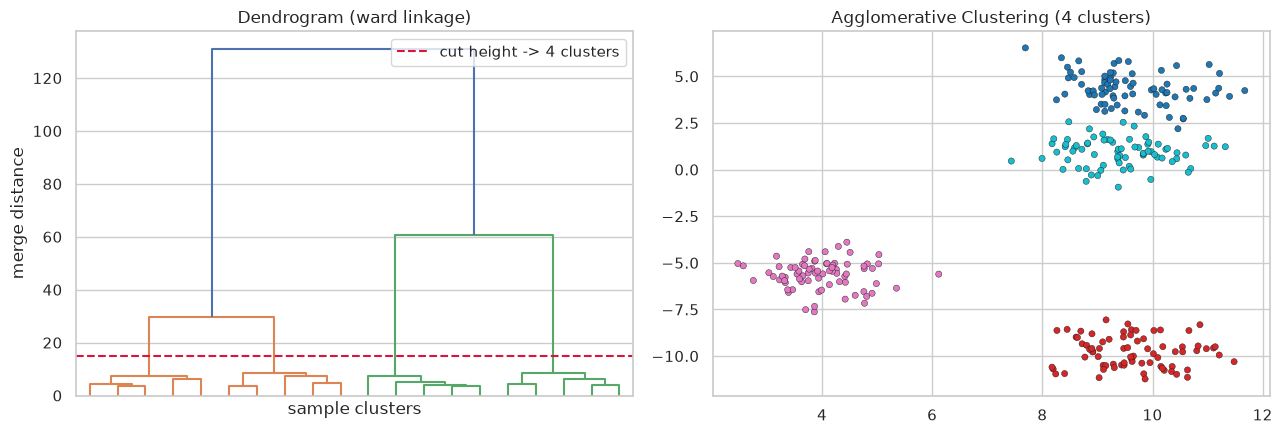

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

Z = linkage(X_blobs, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
dendrogram(Z, ax=axes[0], truncate_mode="lastp", p=20, no_labels=True)
axes[0].axhline(15, color="crimson", linestyle="--", label="cut height -> 4 clusters")
axes[0].set_title("Dendrogram (ward linkage)")
axes[0].set_xlabel("sample clusters")
axes[0].set_ylabel("merge distance")
axes[0].legend()

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
agg_labels = agg.fit_predict(X_blobs)
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=agg_labels, cmap="tab10", s=20, edgecolor="k", linewidth=0.3)
axes[1].set_title("Agglomerative Clustering (4 clusters)")
plt.tight_layout()
plt.show()

## 3. DBSCAN

**Theory.** A **density-based** method: clusters are regions of closely
packed points (at least `min_samples` points within radius `eps`), separated
by regions of low density. Doesn't require choosing `k` in advance, can find
**arbitrarily shaped** clusters, and naturally labels sparse points as
**noise** (`label = -1`). K-Means, by contrast, assumes convex/spherical
clusters and forces every point into one — it fails badly on non-convex
shapes like the moons below.

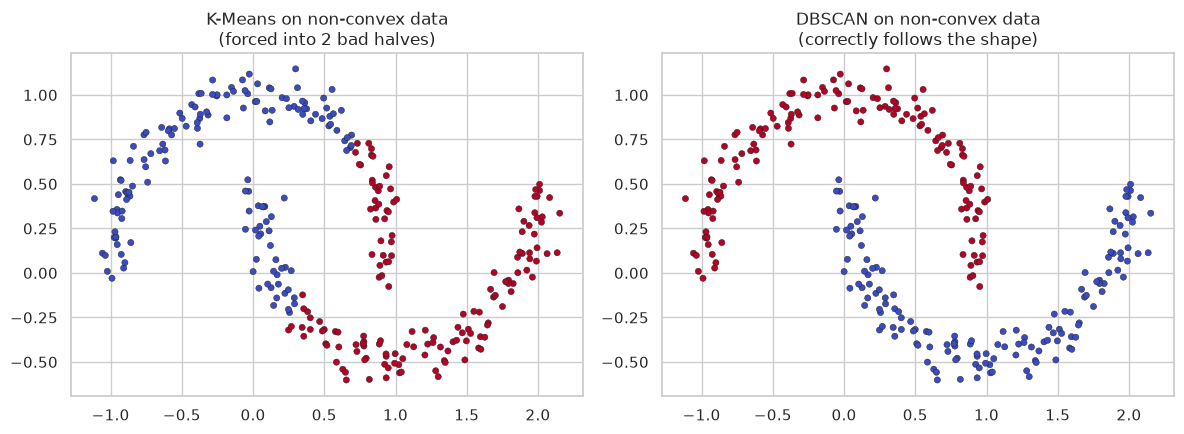

In [5]:
from sklearn.cluster import DBSCAN

X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=4)

kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=4).fit_predict(X_moons)
dbscan_moons = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moons, cmap="coolwarm", s=20, edgecolor="k", linewidth=0.3)
axes[0].set_title("K-Means on non-convex data\n(forced into 2 bad halves)")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_moons, cmap="coolwarm", s=20, edgecolor="k", linewidth=0.3)
axes[1].set_title("DBSCAN on non-convex data\n(correctly follows the shape)")
plt.tight_layout()
plt.show()

This is the clearest illustration of *why* algorithm choice matters: K-Means'
spherical-cluster assumption breaks down completely on crescent-shaped
data, while DBSCAN — which only cares about local density — traces the
shape correctly.

## 4. PCA (Principal Component Analysis)

**Theory.** Finds the directions (principal components) along which the
data varies the most, and projects onto the top few. Each component is a
linear combination of the original features, ordered by how much variance it
explains. Used to compress high-dimensional data, visualize it in 2D/3D, or
remove correlated/redundant features before modeling.

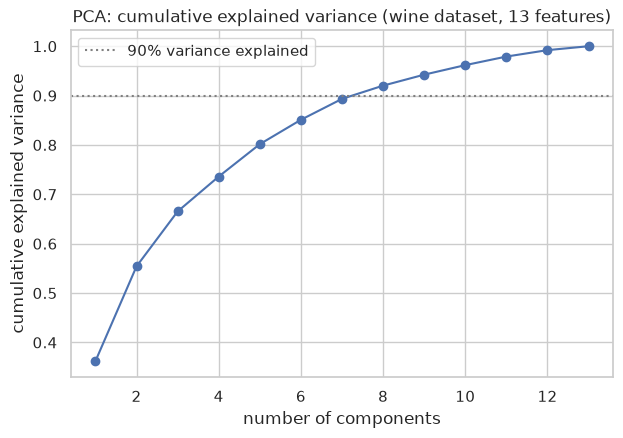

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine_s = StandardScaler().fit_transform(wine.data)

pca = PCA().fit(X_wine_s)

plt.figure(figsize=(7, 4.5))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.9, color="gray", linestyle=":", label="90% variance explained")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.title("PCA: cumulative explained variance (wine dataset, 13 features)")
plt.legend()
plt.show()

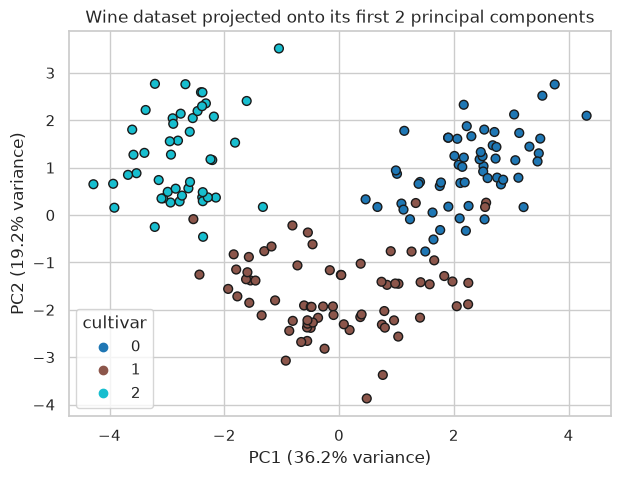

In [7]:
pca_2d = PCA(n_components=2)
X_wine_2d = pca_2d.fit_transform(X_wine_s)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=wine.target, cmap="tab10", edgecolor="k", s=40)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Wine dataset projected onto its first 2 principal components")
plt.legend(*scatter.legend_elements(), title="cultivar")
plt.show()

The 3 wine cultivars (never given to PCA — it only saw `X`, not `y`) fall
into visibly separate regions using just 2 of the original 13 features'
worth of combined variance. That's the payoff of dimensionality reduction:
a 13D dataset becomes plottable, with most of its structure intact.

## 5. t-SNE (t-distributed Stochastic Neighbor Embedding)

**Theory.** Unlike PCA (linear, preserves global variance), t-SNE is a
**non-linear** technique purpose-built for 2D/3D *visualization*: it tries
to keep points that are close in high-dimensional space close in the low-
dimensional embedding, at the expense of preserving global distances or
being invertible. Great for exploring cluster structure; not meant as a
general-purpose preprocessing step before modeling (unlike PCA).

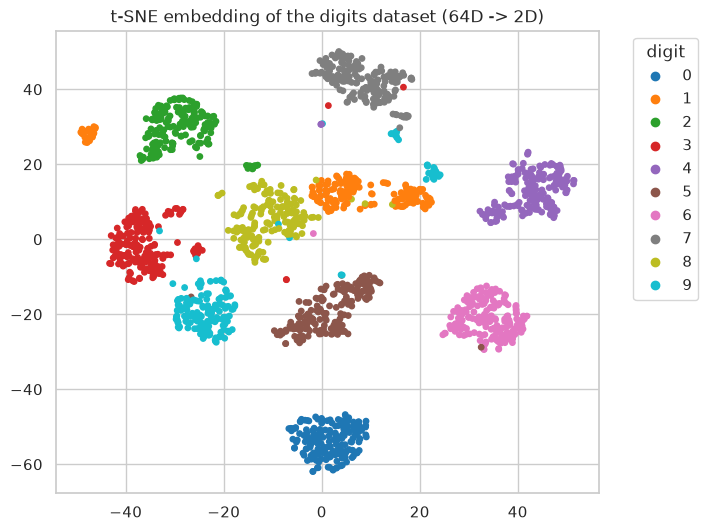

In [8]:
from sklearn.manifold import TSNE

digits = load_digits()  # 8x8 images of handwritten digits, 64 features
tsne = TSNE(n_components=2, random_state=4, perplexity=30)
X_digits_tsne = tsne.fit_transform(digits.data)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], c=digits.target, cmap="tab10", s=15)
plt.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.05, 1))
plt.title("t-SNE embedding of the digits dataset (64D -> 2D)")
plt.show()

Each handwritten digit (0-9) clusters into its own tight island — impressive,
given t-SNE never saw the labels. Compare this to what plain PCA would give
on the same data (try it as an exercise) — t-SNE typically separates classes
more crisply because it optimizes specifically for preserving local
neighborhoods.

## 6. Anomaly Detection

**Theory.** Identify points that don't resemble the rest of the data.

- **Isolation Forest** — randomly partitions the data with trees; anomalies
  are "isolated" (separated into their own leaf) in far fewer splits than
  normal points, since they sit in sparse regions.
- **One-Class SVM** — learns a boundary around the "normal" region of the
  data (in kernel space) and flags anything outside it.

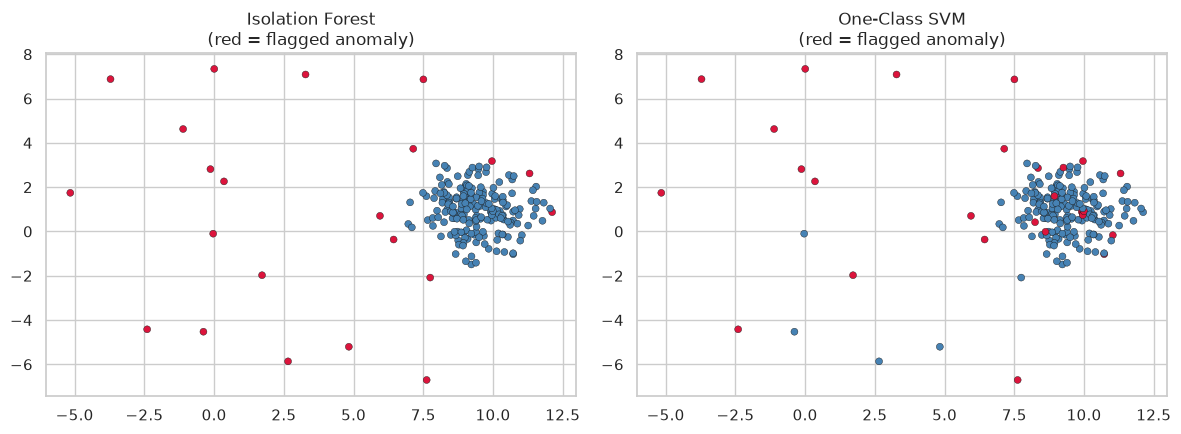

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

X_normal, _ = make_blobs(n_samples=200, centers=1, cluster_std=1.0, random_state=4)
X_outliers = rng.uniform(-8, 8, size=(20, 2))
X_anomaly = np.vstack([X_normal, X_outliers])

iso_forest = IsolationForest(contamination=0.1, random_state=4)
iso_labels = iso_forest.fit_predict(X_anomaly)  # -1 = anomaly, 1 = normal

ocsvm = OneClassSVM(nu=0.1, kernel="rbf", gamma="auto")
ocsvm_labels = ocsvm.fit_predict(X_anomaly)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, labels, title in zip(axes, [iso_labels, ocsvm_labels], ["Isolation Forest", "One-Class SVM"]):
    ax.scatter(X_anomaly[:, 0], X_anomaly[:, 1], c=np.where(labels == -1, "crimson", "steelblue"), s=25, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{title}\n(red = flagged anomaly)")
plt.tight_layout()
plt.show()

Both methods correctly flag most of the scattered outlier points (red) while
leaving the dense central blob (blue) alone — though they don't agree on
every borderline point, which is normal; anomaly detection is inherently
about a threshold judgment call (`contamination`/`nu`), not a ground truth.

## Exercises

1. Change `cluster_std` in the K-Means blobs example to `2.5` (more overlap) — does the elbow/silhouette method still cleanly point to k=4?
2. Try `DBSCAN(eps=0.1, min_samples=5)` on the moons data (smaller `eps`) — what happens to the number of points labeled as noise (-1)?
3. Project the digits dataset with plain `PCA(n_components=2)` instead of t-SNE, and compare the resulting scatter plot's cluster separation.

## Key Takeaways

- K-Means is fast and simple but assumes spherical, similarly-sized clusters and needs `k` chosen upfront (elbow/silhouette help).
- Hierarchical clustering trades speed for not needing to commit to `k` in advance, and gives you the full merge dendrogram.
- DBSCAN handles arbitrary cluster shapes and noise, at the cost of two hyperparameters (`eps`, `min_samples`) that need tuning per dataset.
- PCA is linear and good for general dimensionality reduction/preprocessing; t-SNE is non-linear and best reserved for visualization.
- Anomaly detection methods make a threshold judgment call — there's rarely a single "correct" contamination rate.